In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os

data_path = ""
csv_path = "C:/Users/zoran/OneDrive/Desktop/house price prediction/housing.csv"

if os.path.exists(csv_path):
    data_path = csv_path
    data = pd.read_csv(data_path, sep=",")
    print("Data imported")
else:
    raise FileNotFoundError(f"File not found: {data_path}")

Data imported


In [3]:
data.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [6]:
data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

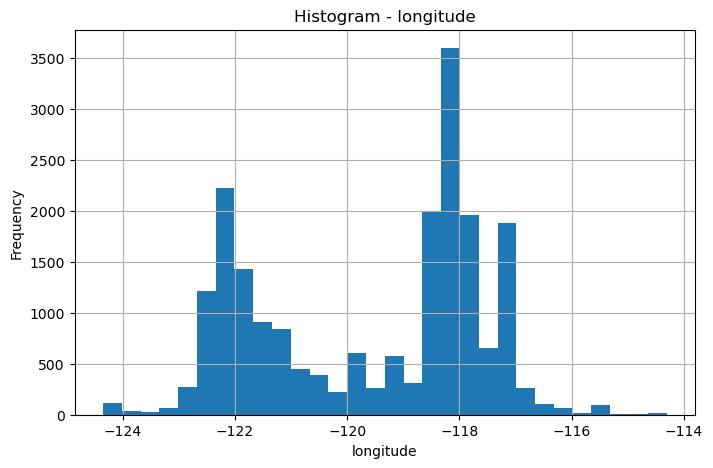

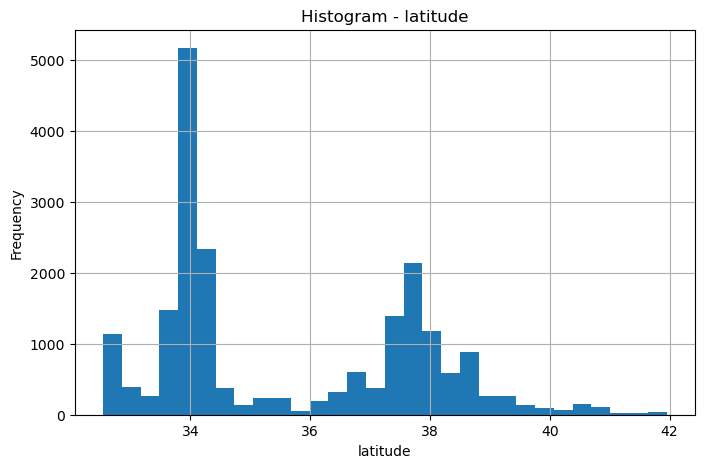

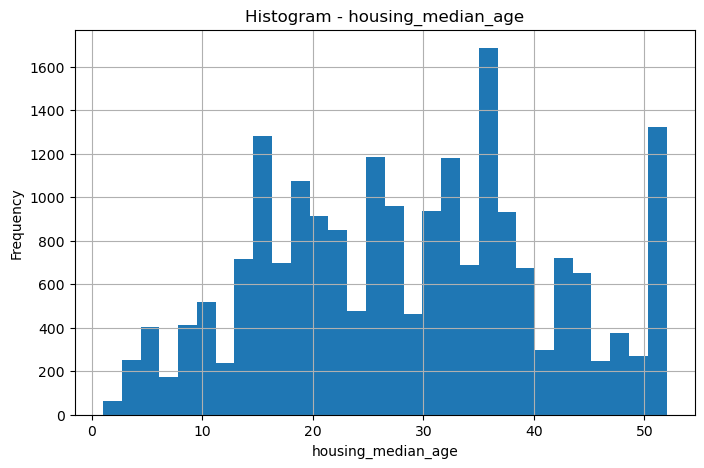

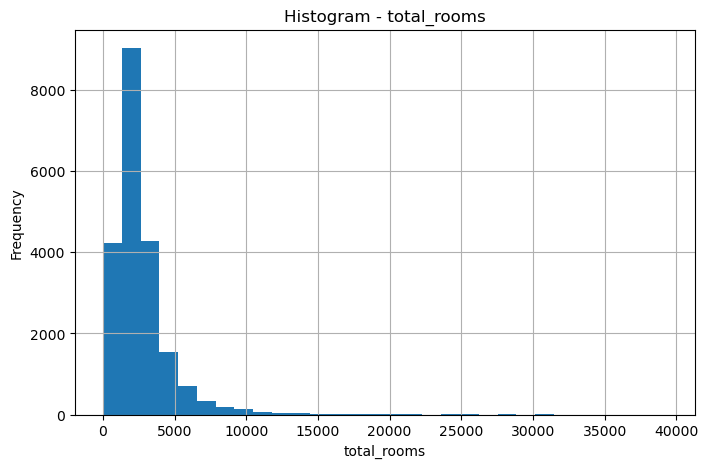

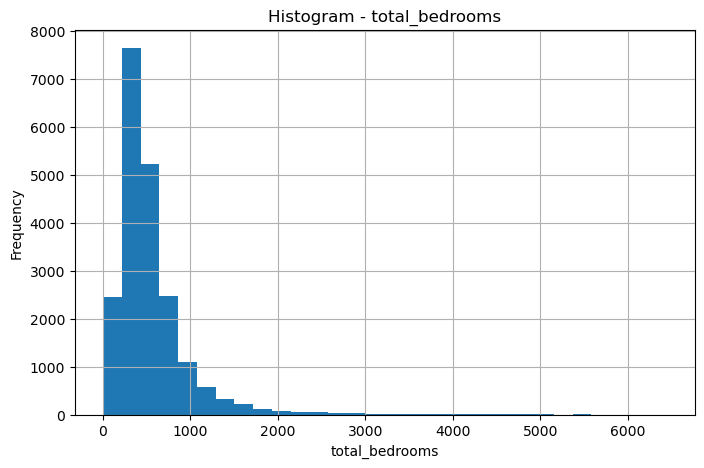

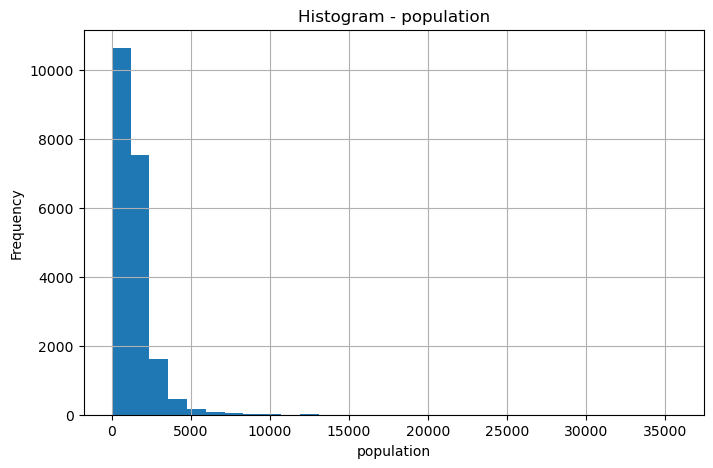

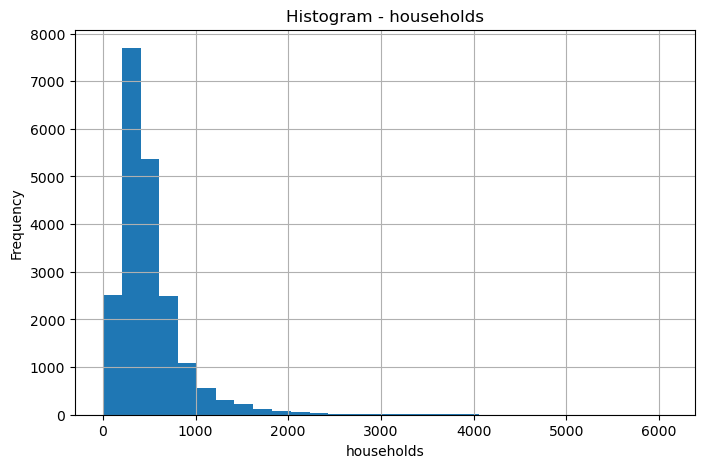

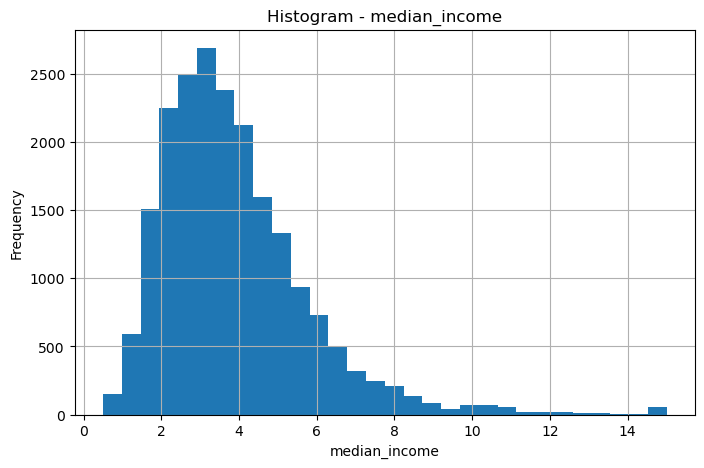

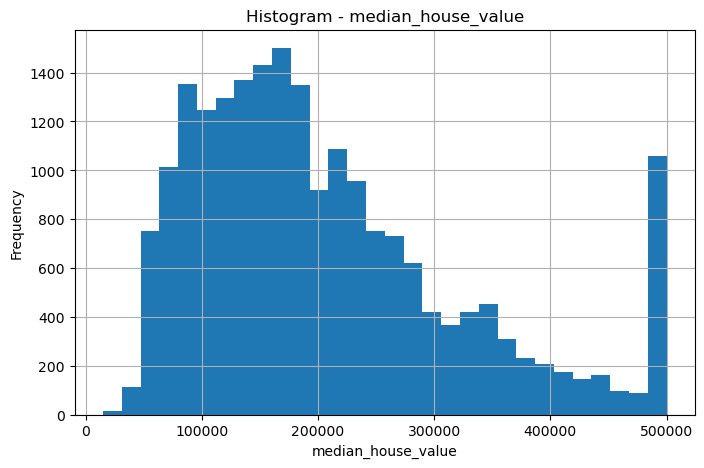

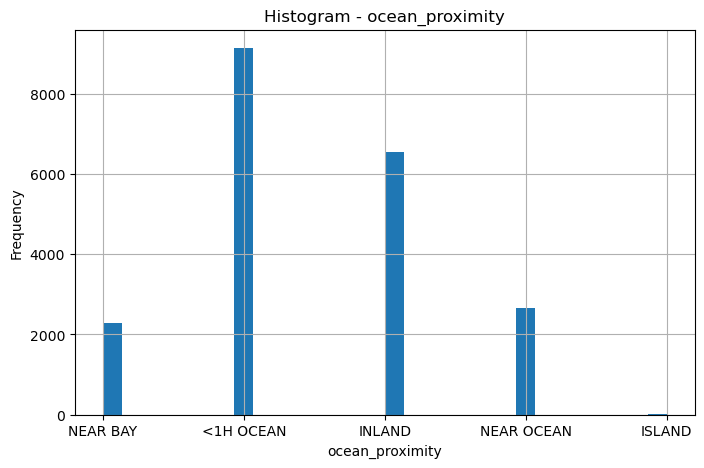

In [7]:
for c in data.columns:
    data[c].hist(figsize=(8,5), bins=30)
    plt.title(f"Histogram - {c}")
    plt.xlabel(c)
    plt.ylabel("Frequency")
    plt.show()

In [8]:
numeric_data = [c for c in data.columns if pd.api.types.is_numeric_dtype(data[c]) == True]

print(numeric_data)

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


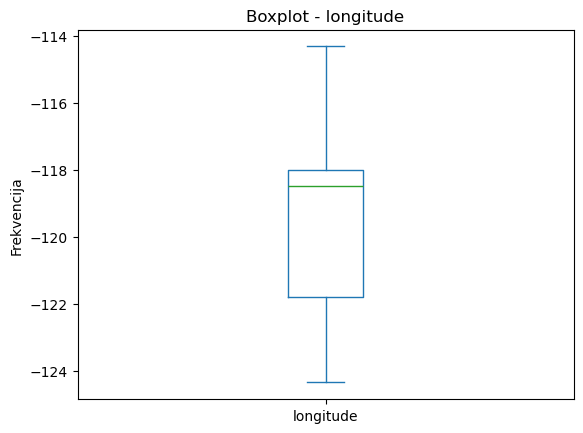

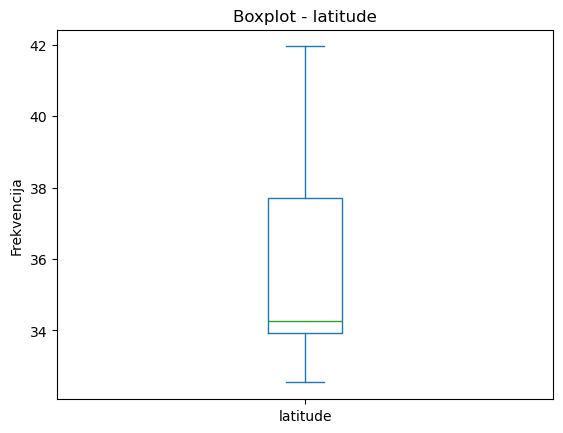

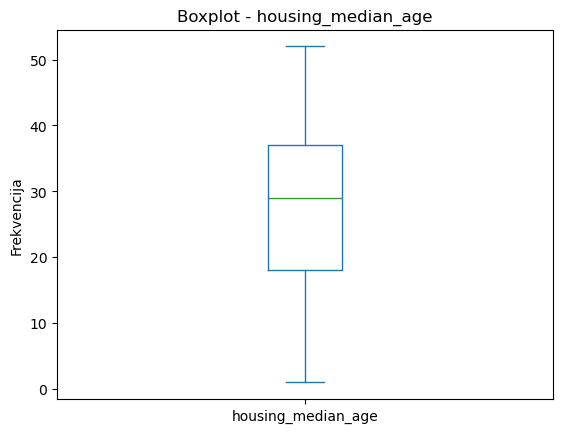

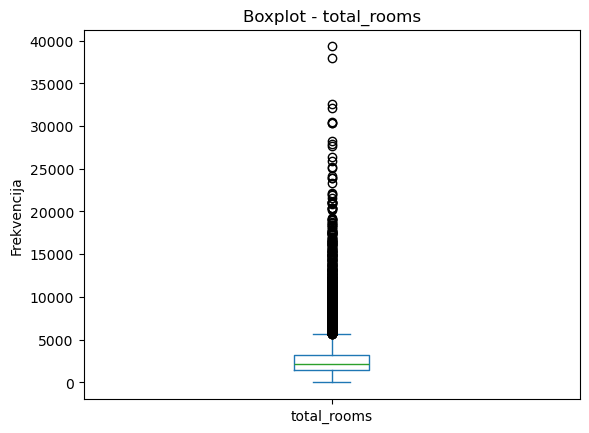

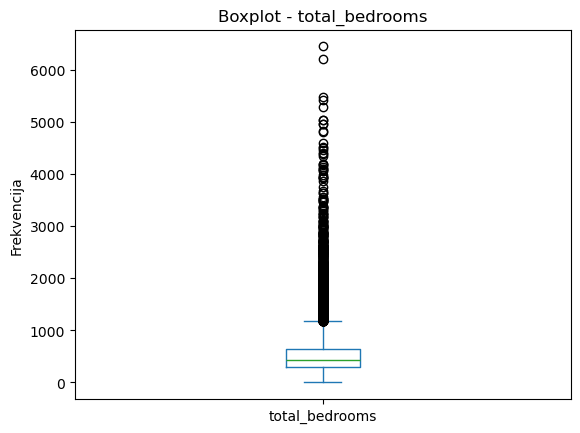

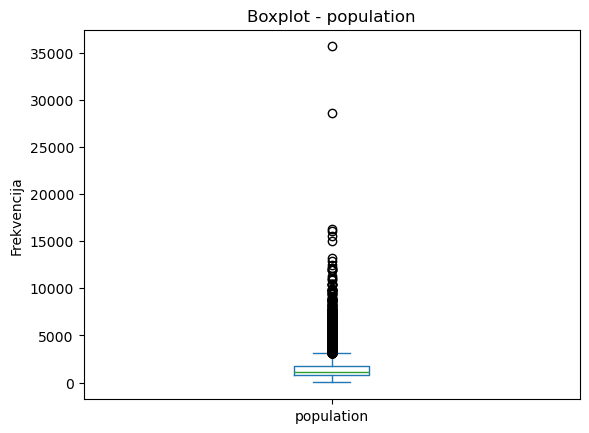

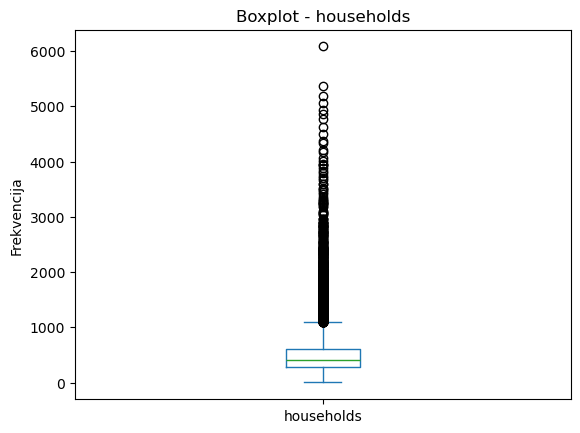

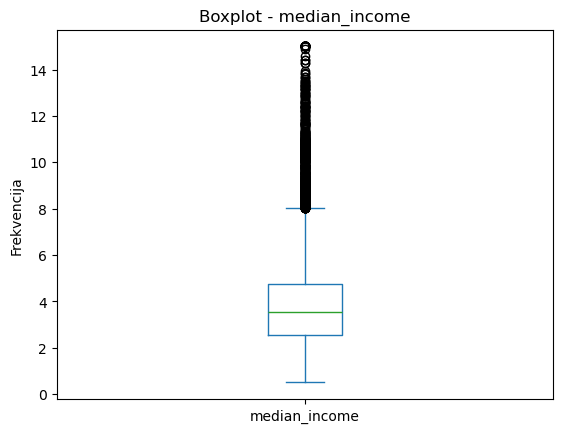

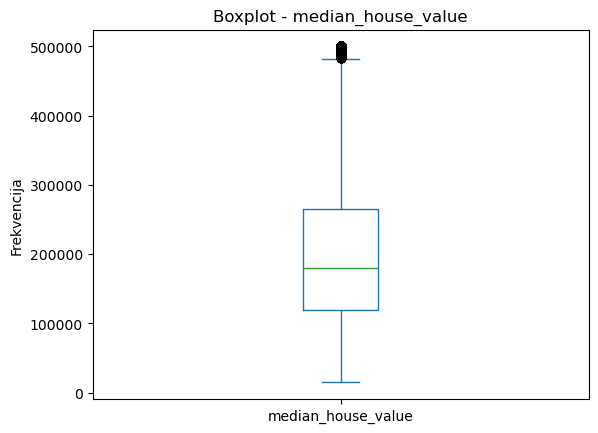

In [9]:
for c in numeric_data:
    data[c].plot(kind = "box")
    plt.title(f"Boxplot - {c}")
    plt.ylabel("Frekvencija")
    plt.show()

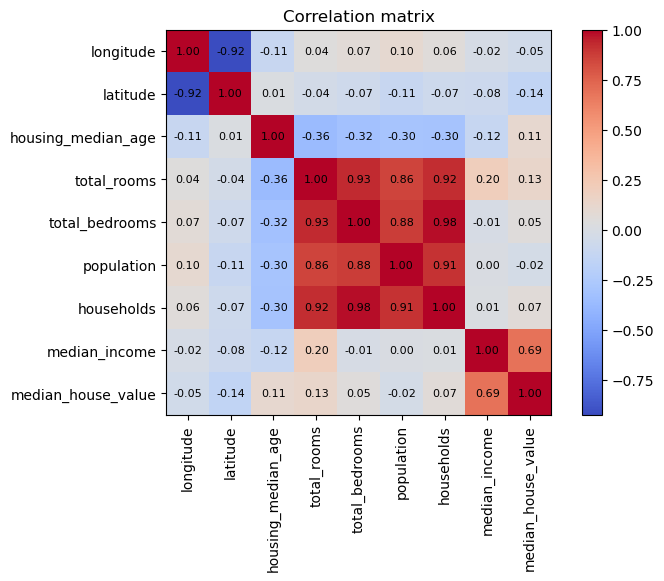

In [10]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(8,5))
plt.imshow(corr, interpolation="nearest", cmap="coolwarm")
plt.colorbar()

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", fontsize = 8, ha = "center", va = "center", color = "black")

plt.title("Correlation matrix")
plt.xticks(range(len(numeric_data)), numeric_data, rotation = 90)
plt.yticks(range(len(numeric_data)), numeric_data)
plt.show()

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [12]:
data["total_bedrooms"] = data["total_bedrooms"].fillna(data["total_bedrooms"].median())

In [13]:
data.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [14]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

In [15]:
encoded_cols = encoder.fit_transform(data[["ocean_proximity"]])
encoded_df = pd.DataFrame(
    encoded_cols.toarray(),
    columns=encoder.get_feature_names_out(["ocean_proximity"])
)
encoded_df.head()

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0


In [16]:
data = data.drop("ocean_proximity", axis = 1)

In [17]:
data = pd.concat([data, encoded_df], axis=1)
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_<1H OCEAN   20640 non-null  float64
 10  ocean_proximity_INLAND      20640 non-null  float64
 11  ocean_proximity_ISLAND      20640 non-null  float64
 12  ocean_proximity_NEAR BAY    20640 non-null  float64
 13  ocean_proximity_NEAR OCEAN  206

In [19]:
data["room_per_households"] = (data["total_rooms"] / data["households"]) 
data["bedrooms_per_room"] = (data["total_bedrooms"] / data["total_rooms"]) 
data["population_per_household"] = (data["population"] / data["households"])

In [20]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,room_per_households,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0,6.281853,0.172096,2.181467


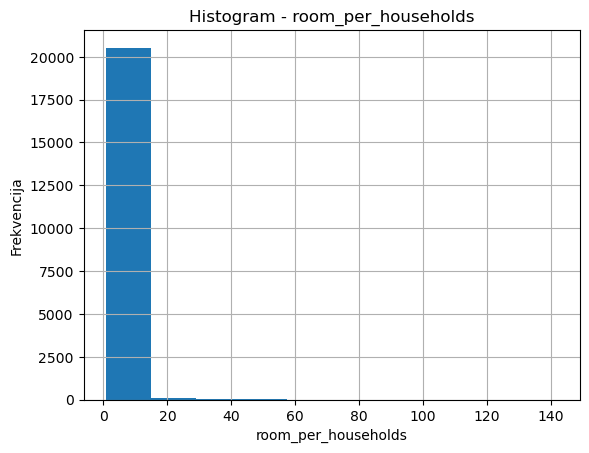

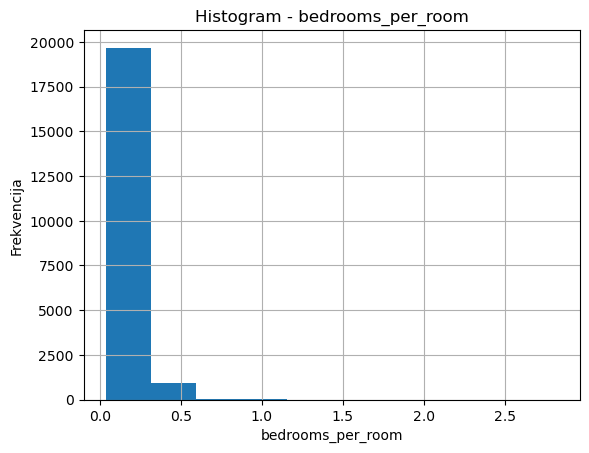

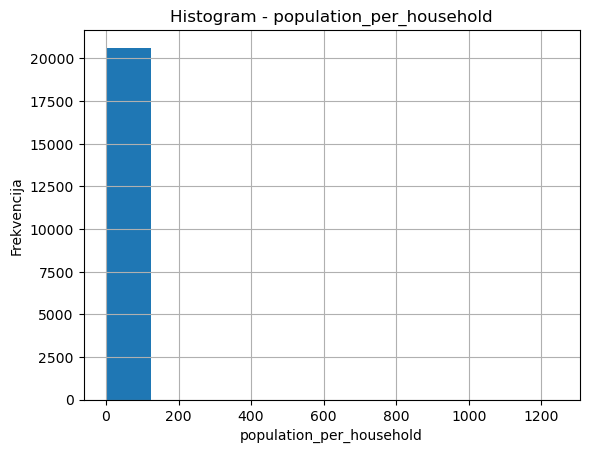

In [21]:
new_features = ["room_per_households", "bedrooms_per_room", "population_per_household"]
for c in new_features:
    data[c].hist()
    plt.title(f"Histogram - {c}")
    plt.xlabel(c)
    plt.ylabel("Frekvencija")
    plt.show()

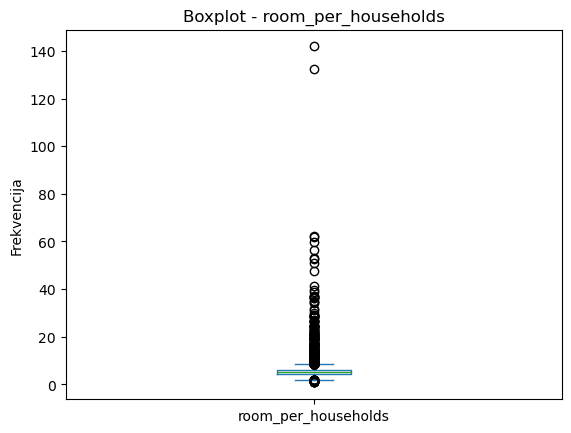

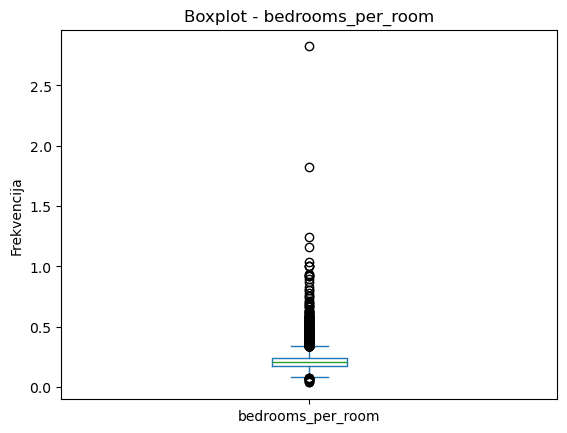

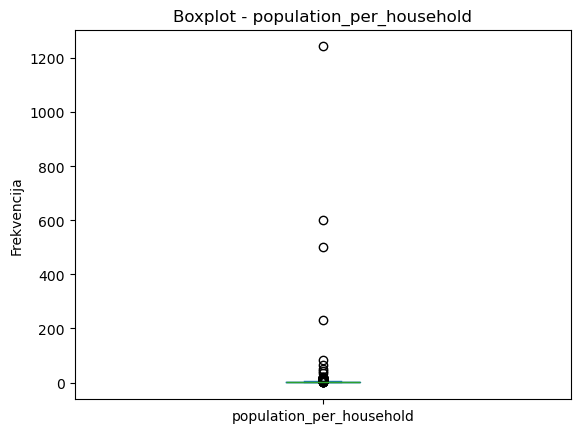

In [22]:
for c in new_features:
    data[c].plot(kind="box")
    plt.title(f"Boxplot - {c}")
    plt.ylabel("Frekvencija")
    plt.show()

In [23]:
data.sort_values("room_per_households", ascending=False).head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,room_per_households,bedrooms_per_room,population_per_household
1914,-120.10,38.91,33.0,1561.0,282.0,30.0,11.0,1.8750,500001.0,0.0,1.0,0.0,0.0,0.0,141.909091,0.180653,2.727273
1979,-120.08,38.80,34.0,1988.0,511.0,36.0,15.0,4.6250,162500.0,0.0,1.0,0.0,0.0,0.0,132.533333,0.257042,2.400000
12447,-114.49,33.97,17.0,2809.0,635.0,83.0,45.0,1.6154,87500.0,0.0,1.0,0.0,0.0,0.0,62.422222,0.226059,1.844444
1913,-120.06,39.01,19.0,2967.0,528.0,112.0,48.0,4.0714,437500.0,0.0,1.0,0.0,0.0,0.0,61.812500,0.177958,2.333333
11862,-121.25,40.27,25.0,958.0,245.0,28.0,16.0,2.6250,67500.0,0.0,1.0,0.0,0.0,0.0,59.875000,0.255741,1.750000
1912,-120.16,39.01,16.0,1463.0,264.0,54.0,26.0,4.9750,206300.0,0.0,1.0,0.0,0.0,0.0,56.269231,0.180451,2.076923
9676,-119.02,37.64,14.0,5919.0,1278.0,265.0,112.0,3.2431,221400.0,0.0,1.0,0.0,0.0,0.0,52.848214,0.215915,2.366071
11707,-120.06,39.15,22.0,2213.0,372.0,98.0,42.0,1.1912,170000.0,0.0,1.0,0.0,0.0,0.0,52.690476,0.168098,2.333333
2395,-119.34,37.12,23.0,1881.0,380.0,64.0,37.0,3.8750,125000.0,0.0,1.0,0.0,0.0,0.0,50.837838,0.202020,1.729730
1240,-120.19,38.42,11.0,1568.0,369.0,82.0,33.0,3.1250,77500.0,0.0,1.0,0.0,0.0,0.0,47.515152,0.235332,2.484848


In [24]:
data["room_per_households"].describe()

count    20640.000000
mean         5.429000
std          2.474173
min          0.846154
25%          4.440716
50%          5.229129
75%          6.052381
max        141.909091
Name: room_per_households, dtype: float64

In [25]:
data_log = pd.DataFrame()

for c in new_features:
    data_log[f"{c}_log"] = np.log1p(data[c])

data_log.head(10)

,room_per_households_log,bedrooms_per_room_log,population_per_household_log
0,2.077455,0.136793,1.268511
1,1.979364,0.144790,1.134572
2,2.228738,0.121789,1.335596
3,1.919471,0.169286,1.266369
4,1.985385,0.158793,1.157342
5,1.751225,0.208455,1.144190
6,1.780346,0.176387,1.140523
7,1.757431,0.199938,1.025415
8,1.666596,0.231329,1.107536
9,1.786845,0.181664,1.154447


In [26]:
data_log.describe().T

,count,mean,std,min,25%,50%,75%,max
room_per_households_log,20640.0,1.828722,0.231938,0.613104,1.693911,1.829236,1.953365,4.962209
bedrooms_per_room_log,20640.0,0.192486,0.049034,0.036477,0.161459,0.184951,0.215213,1.341474
population_per_household_log,20640.0,1.351645,0.207530,0.526093,1.232485,1.339757,1.454481,7.126355


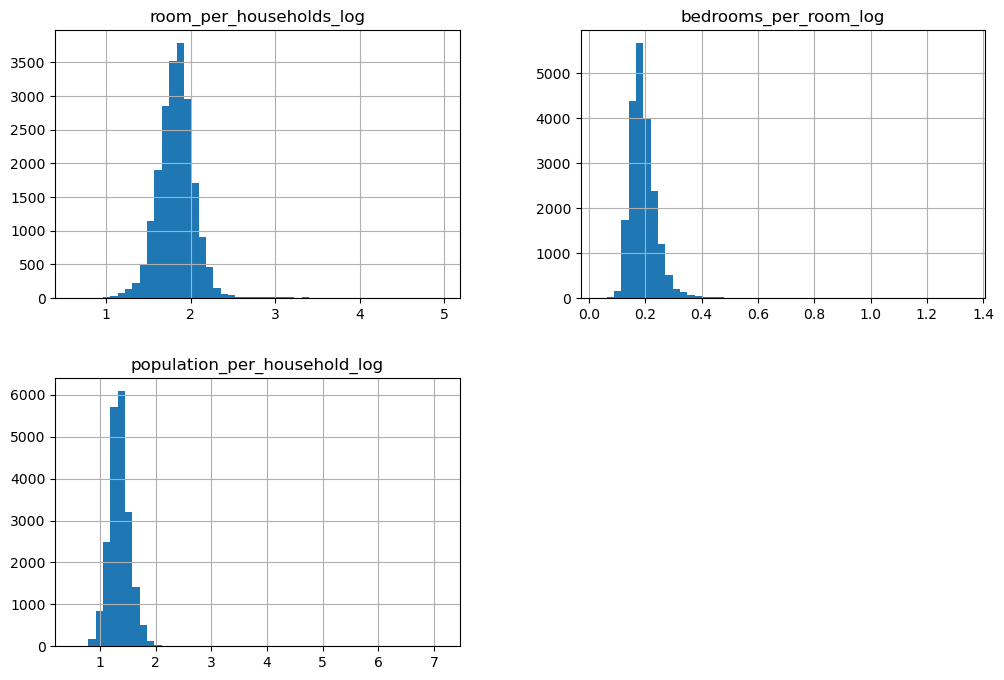

In [27]:
data_log[[c for c in data_log.columns]].hist(bins=50, figsize=(12,8))
plt.show()

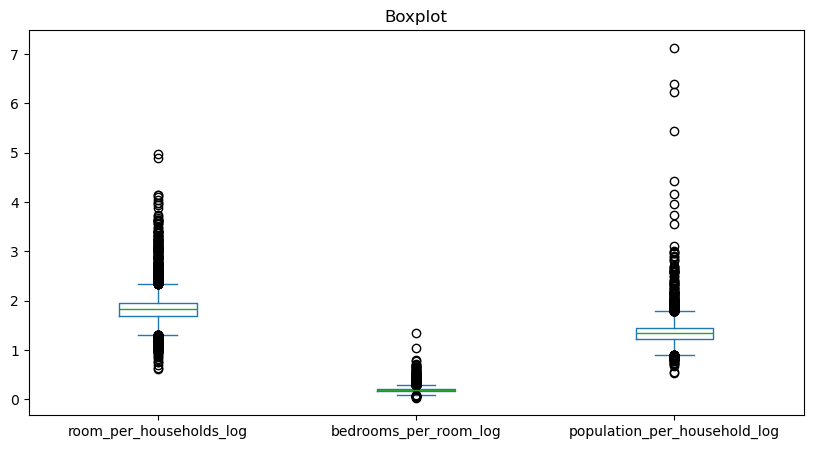

In [28]:
data_log[[c for c in data_log.columns]].plot(kind="box", figsize=(10,5))
plt.title("Boxplot")
plt.show()

In [29]:
df_model = data.copy()
df_model.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,room_per_households,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0,6.281853,0.172096,2.181467


In [30]:
df_model = df_model.drop(["room_per_households", "bedrooms_per_room", "population_per_household"], axis = 1)
df_model = pd.concat([df_model, data_log], axis=1)

In [31]:
df_model.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,room_per_households_log,bedrooms_per_room_log,population_per_household_log
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0,2.077455,0.136793,1.268511
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0,1.979364,0.144790,1.134572
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0,2.228738,0.121789,1.335596
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0,1.919471,0.169286,1.266369
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0,1.985385,0.158793,1.157342


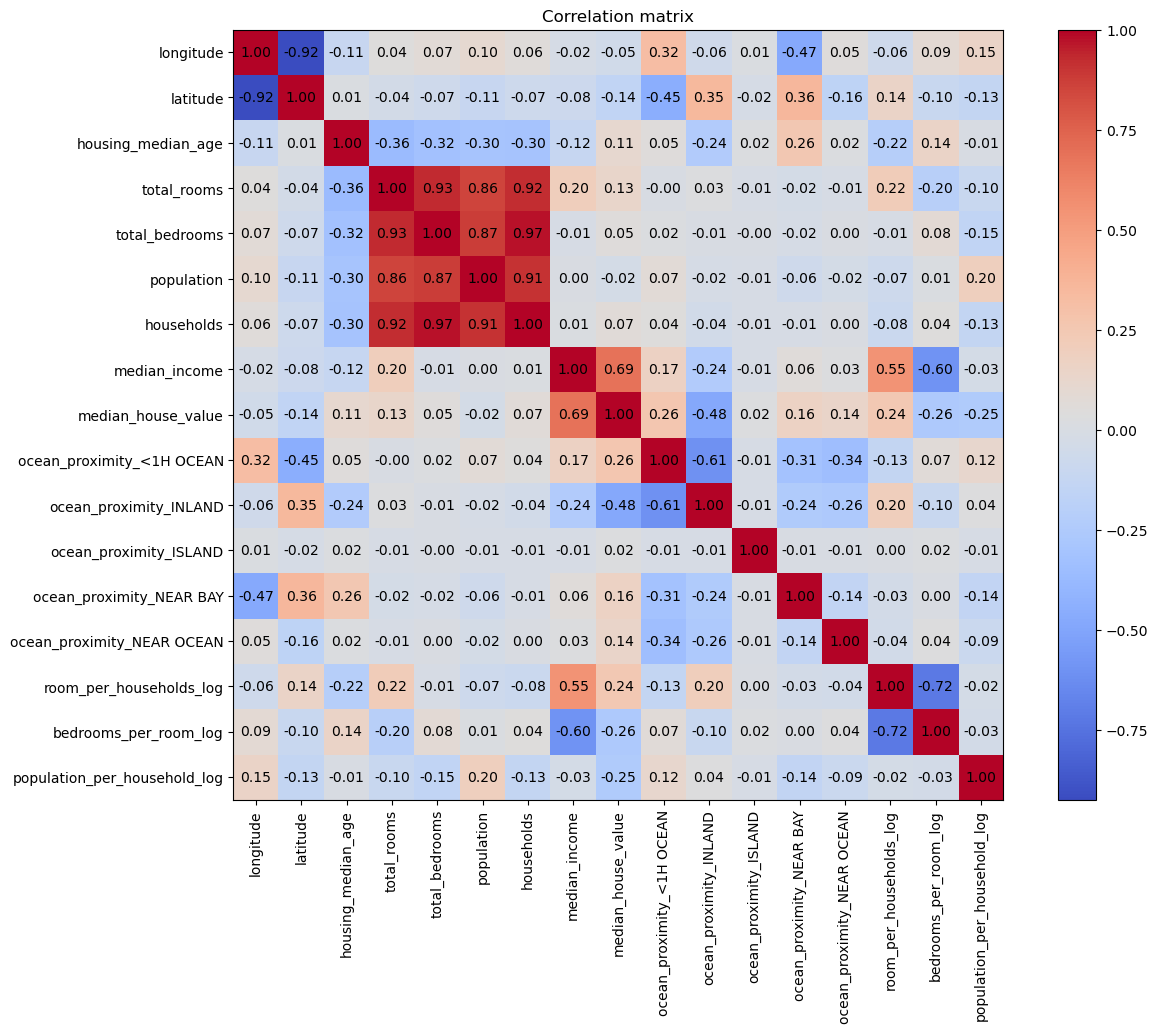

In [32]:
corr = df_model.corr(numeric_only=True)

plt.figure(figsize=(14,10))

plt.xticks(range(len(corr.columns)), corr.columns, rotation = 90)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha = "center", va = "center")

plt.imshow(corr, interpolation="nearest", cmap="coolwarm")
plt.colorbar()
plt.title("Correlation matrix")
plt.show()


In [33]:
X = df_model.drop("median_house_value", axis = 1)
y = df_model["median_house_value"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,room_per_households_log,bedrooms_per_room_log,population_per_household_log
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,0.0,0.0,0.0,0.0,1.0,1.794698,0.182801,1.545819
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,0.0,0.0,0.0,0.0,1.0,1.699926,0.209209,1.007263
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,0.0,0.0,0.0,0.0,1.0,1.893990,0.160831,1.314587
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,0.0,0.0,0.0,0.0,1.0,1.610001,0.229737,1.608311
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,0.0,1.0,0.0,0.0,0.0,1.983539,0.166311,1.193922
